# MNIST Autoencoder

Training a convolutional autoencoder to reconstruct MNIST digits with PyTorch Lightning.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina', 'svg']

import os

import matplotlib.pyplot as plt
import torch
from lightning import Trainer
from torchinfo import summary

from chimera.data import MNISTDataModule
from chimera.modules import AutoencoderModule
from chimera.optim import LinearWarmupCosineAnnealingLR

os.environ["DATA_DIR"] = "../../../data"

## Data

Load MNIST without normalization so pixels stay in `[0, 1]`, matching the decoder's sigmoid output.

In [ ]:
dm = MNISTDataModule(
    pin_memory=False,
    num_workers=0,
    data_dir=os.environ["DATA_DIR"],
)
dm.prepare_data()
dm.setup("fit")

train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

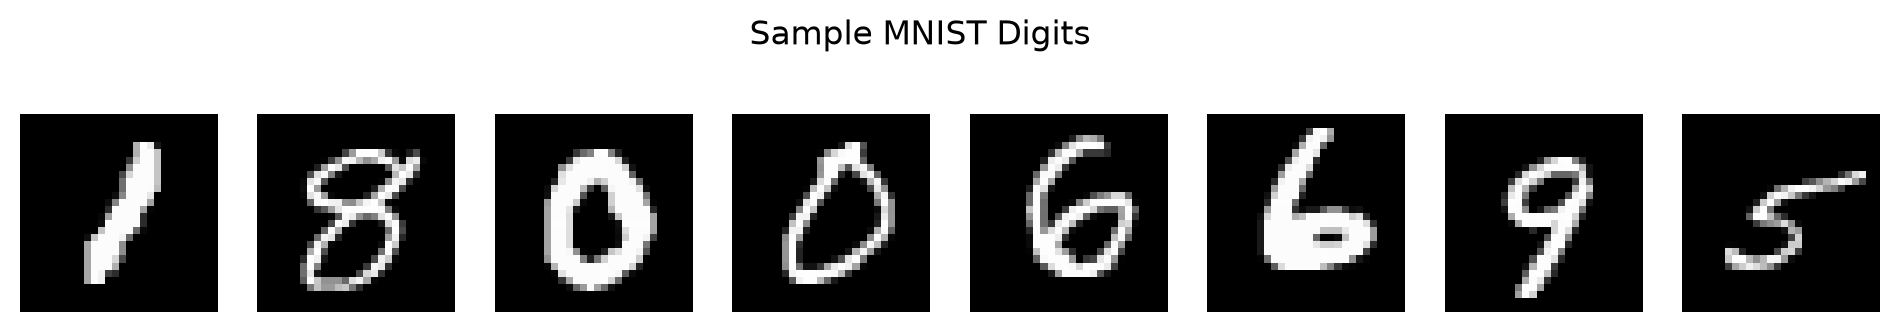

In [3]:
images, _ = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
fig.suptitle("Sample MNIST Digits")
for ax, img in zip(axes, images):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.show()

## Model

A convolutional autoencoder: the encoder compresses each 28x28 image to a latent vector, and the decoder reconstructs it.

In [ ]:
from chimera.models import DigitDreamerAE

model = DigitDreamerAE(in_channels=1, latent_dim=32)
summary(
    model,
    input_size=(1, 1, 28, 28),
    col_names=["output_size", "mult_adds", "num_params"],
    verbose=0,
)

## Training

Wrap the model in a `LightningModule` and train with a linear-warmup cosine-annealing schedule, minimizing reconstruction MSE.

In [6]:
N_EPOCH = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = LinearWarmupCosineAnnealingLR(
    optimizer,
    warmup_steps=1000,
    n_epochs=N_EPOCH,
    train_loader=train_loader,
)

autoencoder_module = AutoencoderModule(model, optimizer, scheduler)

trainer = Trainer(
    max_epochs=N_EPOCH,
    precision="bf16-true",
)

trainer.fit(
    autoencoder_module, train_dataloaders=train_loader, val_dataloaders=val_loader
)
trainer.test(autoencoder_module, dataloaders=val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type        | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model     | Autoencoder | 111 K  | train | 0    
1 | criterion | MSELoss     | 0      | train | 0    
----------------------------------------------------------
111 K     Trainable params
0         Non-trainable params
111 K     Total params
0.223     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
/Users/karan/Code/projects/chimera/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss          0.010188802145421505
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test/loss': 0.010188802145421505}]

## Analysis

Plot the logged reconstruction loss curves, then compare original digits against their reconstructions.

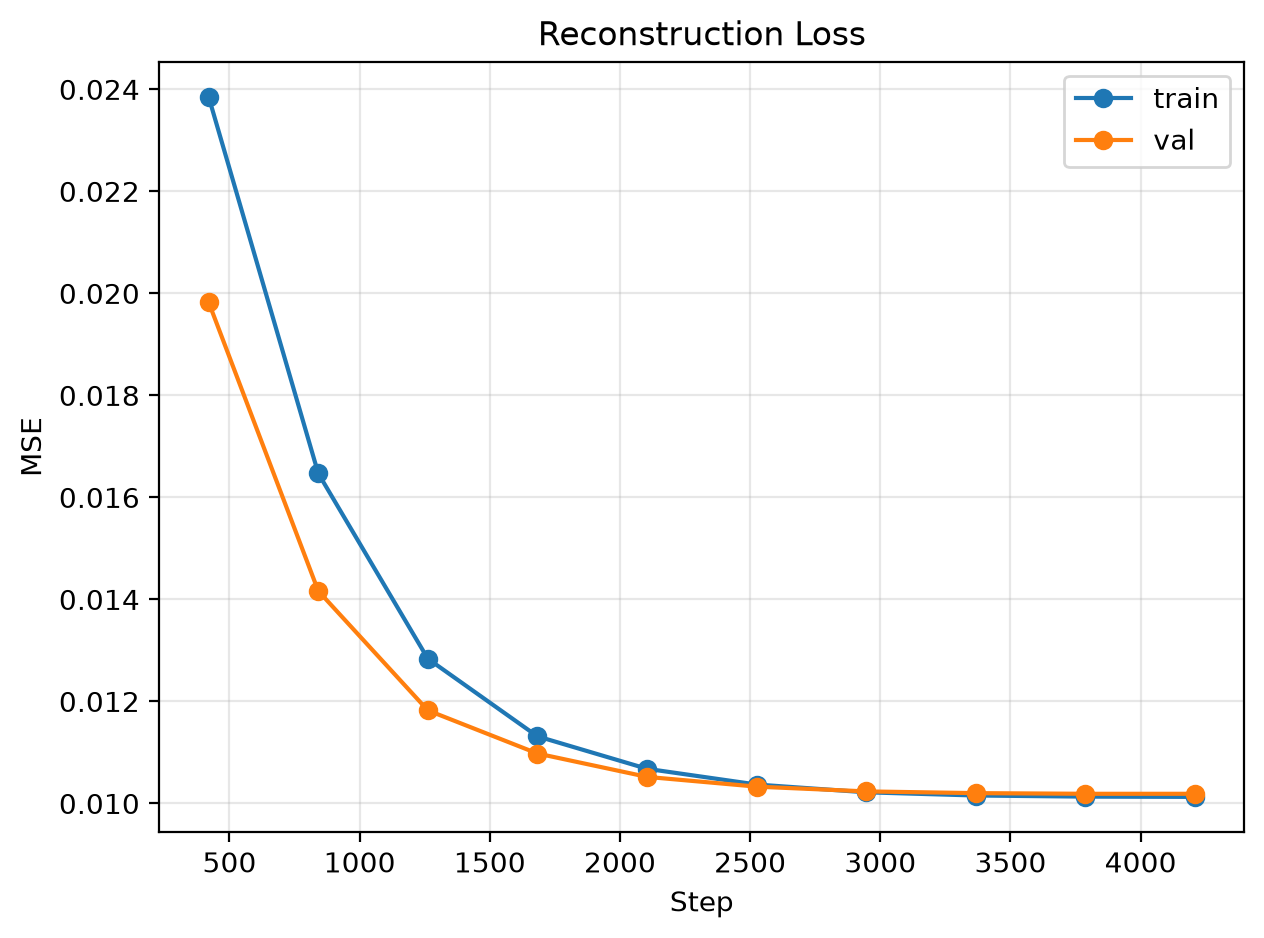

In [7]:
import numpy as np

metrics = np.genfromtxt(
    f"{trainer.logger.log_dir}/metrics.csv", delimiter=",", names=True
)


def series(step_key, value_key):
    step = metrics[step_key]
    value = metrics[value_key]
    mask = ~np.isnan(value)
    return step[mask], value[mask]


plt.figure(figsize=(7, 5))
plt.title("Reconstruction Loss")
train_step, train_val = series("step", "trainloss_epoch")
val_step, val_val = series("step", "valloss")
plt.plot(train_step, train_val, marker="o", label="train")
plt.plot(val_step, val_val, marker="o", label="val")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

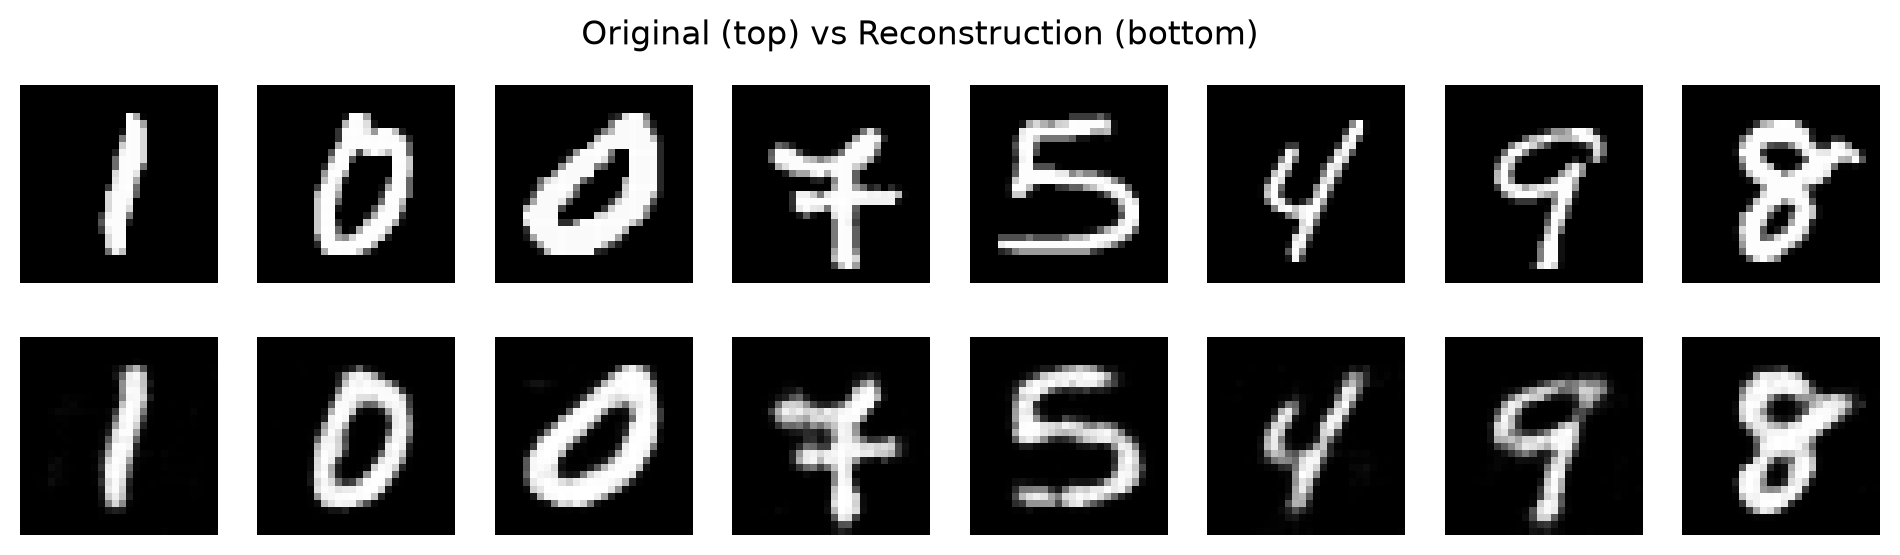

In [ ]:
autoencoder_module.eval()
device = autoencoder_module.device

images, _ = next(iter(val_loader))
with torch.no_grad():
    recons = (
        autoencoder_module(images.to(device, dtype=autoencoder_module.dtype))
        .float()
        .cpu()
    )

n = 8
fig, axes = plt.subplots(2, n, figsize=(12, 3))
fig.suptitle("Original (top) vs Reconstruction (bottom)")
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
plt.show()